<div class="alert alert-block alert-success">  
<h1><center><strong>Let's Move to Another Dimension 🚀</strong></center></h1>

#### We Use one of the basic Problem in Kaggle: **"Space-ship Titanic Problem"** 

<div>
<img src="https://i.imgur.com/gfg8lWr.jpg?fb">
</div>

<div class="alert alert-info">  
<h3><strong>Import Libraries 📃</strong></h3>
</div>

#### If this helped in your learning, then please **UPVOTE** – as they are the source of motivation!

In [1]:
# download this first then comment it.
# ! pip install -q scikit-plot 

Notebook Color Schemes:


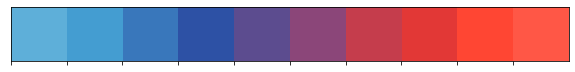

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from mpl_toolkits.axes_grid1 import make_axes_locatable
import scikitplot as skplt

class clr:
    S = '\033[1m' + '\033[94m'
    E = '\033[0m'
    
    
warnings.filterwarnings('ignore')
my_colors = ["#5EAFD9", "#449DD1", "#3977BB", 
             "#2D51A5", "#5C4C8F", "#8B4679",
             "#C53D4C", "#E23836", "#FF4633", "#FF5746"]

print(clr.S+"Notebook Color Schemes:"+clr.E)
sns.palplot(sns.color_palette(my_colors))
plt.show()

<div class="alert alert-info">  
<h3><strong>1. The Problem Statement 📃</strong></h3>
    <p>
    In this kernel, I Explain full roadmap of analyzing the problem statement and then Use EDA to analyze the Data, we convert the raw data into insightful data.



The Dataset is from the competition named **Spaceship-Titanic** which is the tabular type problem and we have some categorical data and some numerical data in this **Spaceship-Titanic** Problem. 

### What we want to Achieve: 
Predict If the Person is Transported to an alternate dimension or Not.

</p>
</div>

<div class="alert alert-info">  
<h3><strong>2. Import Dataset 📃</strong></h3>
</div>

In [3]:
train_data = pd.read_csv('../input/spaceship-titanic/train.csv')
test_data = pd.read_csv('../input/spaceship-titanic/test.csv')

<div class="alert alert-info">  
<h3><strong>3. Exploratory Data Analysis 📊</strong></h3>
</div>

Now I will explore the data and gain insight from the data.

#### **View the Dimensions of the train and test dataset.**


Using function name **.shape** to find the rows and columns of the dataset, it returns the tuple (nrows,ncols) => so nrows shows the total data of the file and ncols shows the features of the file that we will use in future.


**Let's dive into the Data to find Patterns** 😎

In [4]:
# Printing the Shape of the Train and Tet data to find data's instances and features.

print(f'The Shpae of the Train data : {train_data.shape}')
print(f'The Shpae of the Test data : {test_data.shape}')

The Shpae of the Train data : (8693, 14)
The Shpae of the Test data : (4277, 13)


* In Train data we have *8693* instances and *14* features.
* In Test data we have *4277* instances and *13* features.

## Preview the dataset

In [5]:
train_data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [6]:
# This Function used to Print the useful of the csv file

def get_csv(df,name):
    print(clr.S+f" === {name} === "+clr.E)
    print(clr.S+"Total Missing Values : "+clr.E,df.isnull().sum().sum())
    print(clr.S+"Columns = "+clr.E,list(df.columns),"\n\n")
    
get_csv(train_data,'Train')
get_csv(test_data,'Test')

 === Train === 
Total Missing Values :  2324
Columns =  ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported'] 


 === Test === 
Total Missing Values :  1117
Columns =  ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name'] 




<div class="alert alert-info">  
<h3><strong>View summary of dataset 📃</strong></h3>
</div>

In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


#### Findings:
* we can see that dataset contain 7 character data and 6 numerical and 1 boolean
* Transported is the Target Column
* There are Some Missing Values in Some Columns
*  HomePlanet, CryoSleep, Cabin, Destination, Age, VIP, RoomServices, FoodCourt, ShoppingMall, Spa,VRDeck and Name => These Columns have missing values

<div class="alert alert-info">  
<h3><strong>View Statistics of Data 👀</strong></h3>
</div>

In [8]:
train_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,8514.0,28.827930,14.489021,0.0,19.0,27.0,38.0,79.0
RoomService,8512.0,224.687617,666.717663,0.0,0.0,0.0,47.0,14327.0
FoodCourt,8510.0,458.077203,1611.489240,0.0,0.0,0.0,76.0,29813.0
ShoppingMall,8485.0,173.729169,604.696458,0.0,0.0,0.0,27.0,23492.0
Spa,8510.0,311.138778,1136.705535,0.0,0.0,0.0,59.0,22408.0
VRDeck,8505.0,304.854791,1145.717189,0.0,0.0,0.0,46.0,24133.0


#### Important points to note:

* The above command df.describe() helps us to view the statistical properties of numerical variables. It excludes character variables.
* If we want to view the statistical properties of character variables, we should run the following command -

         train_data.describe(include=['object'])

* If we want to view the statistical properties of all the variables, we should run the following command -

       train_data.describe(include='all')



### Key Points to Consider:

* From Checking above Statistical Properties of the train data we concluded that: 
* Columns: Spa, RoomService, VRDeck, ShoppingMall and FoodCourt have outliers

* Spa, RoomService, VRDeck, ShoppingMall and FoodCourt Columns are all about the expenses of Passengers. So, we add them up for every Passenger to Calculate the Total Expense.


#### **Let's Explore More :)** 

<AxesSubplot:xlabel='Transported', ylabel='count'>

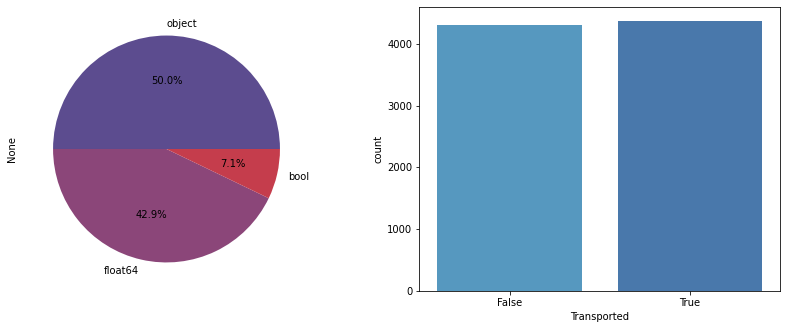

In [9]:
plt.figure(figsize=(22,24))
plt.subplot(4,3,1)
train_data.dtypes.value_counts().plot(kind='pie',autopct='%.1f%%',colors=[my_colors[4],my_colors[5],my_colors[6]])
plt.subplot(4,3,2)
sns.countplot(data=train_data,x='Transported',palette = [my_colors[1],my_colors[2]])

* As we see that Transported Column is balanced.
* 50% of data are categorical and ~43% are Float and 7.1% are boolean

### Checking Nans in the Dataset:

* Using isnull function we will detect the Nans in every column

In [10]:
print(clr.S+" --- Count of Nan's in Every Column --- "+clr.E)
train_data.isnull().sum()

 --- Count of Nan's in Every Column --- 


PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

<AxesSubplot:title={'center':'Count of Nan in Every Columns'}>

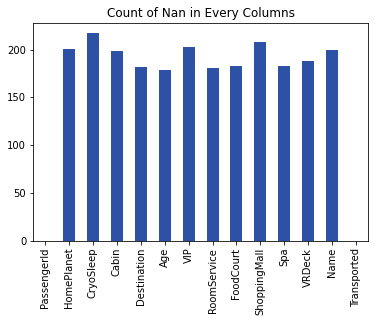

In [11]:
plt.figure(figsize=(6,4))
plt.title('Count of Nan in Every Columns')
train_data.isnull().sum().plot(kind='bar',color=my_colors[3])

In [12]:
print(clr.S+"Percentage of Nan columns in Train data "+clr.E)
round(train_data.isnull().sum() / len(train_data) * 100,2)

Percentage of Nan columns in Train data 


PassengerId     0.00
HomePlanet      2.31
CryoSleep       2.50
Cabin           2.29
Destination     2.09
Age             2.06
VIP             2.34
RoomService     2.08
FoodCourt       2.11
ShoppingMall    2.39
Spa             2.11
VRDeck          2.16
Name            2.30
Transported     0.00
dtype: float64

# Interpretation

* we can see that we have slight Nans in most of the columns.
* We do not drop the Column because we have low percentage of Nan in Columns.
* We Will Use Imputation Techniques to Fill the Nan Columns. we will discuss it later :)

<div class="alert alert-info">  
<h3><strong>First we Analyze Numerical Data</strong></h3>
</div>

In [13]:
# Using select_dtypes we include only numerical data

num_data = train_data.select_dtypes(exclude=['object']).copy()

num_data.head() # confirming that we selected numerical columns

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,39.0,0.0,0.0,0.0,0.0,0.0,False
1,24.0,109.0,9.0,25.0,549.0,44.0,True
2,58.0,43.0,3576.0,0.0,6715.0,49.0,False
3,33.0,0.0,1283.0,371.0,3329.0,193.0,False
4,16.0,303.0,70.0,151.0,565.0,2.0,True


### Summary of Numerical Columns:


* Numericals Columns : *[Age, RoomService, FoodCourt, ShoppingMall, Spa, VRDeck]*
* All Columns are continuous datatype.

#### Checking Age Column:

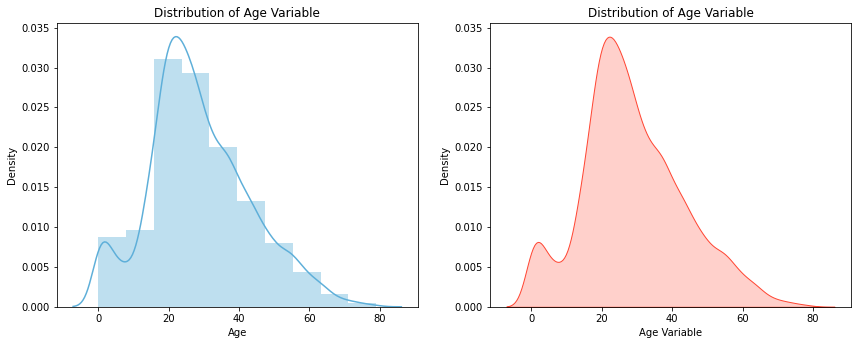

In [14]:
plt.figure(figsize=(22,24))
temp = num_data['Age']
x = pd.Series(temp,name='Age Variable')
plt.subplot(4,3,1)
ax = sns.distplot(temp,bins=10,color=my_colors[0])
ax.set_title("Distribution of Age Variable")
plt.subplot(4,3,2)
ax = sns.kdeplot(x,shade=True,color=my_colors[8])
ax.set_title('Distribution of Age Variable')
plt.show()

#### Interpretation
* We see that Age column is normalized and it is slighlty skewed but not too much so we consider it as Normalized Column. 
* If it is Normalized then, we can say that it does not have Outliers.
* To Confirm Our Hypothesis that Age Column did not have outliers, we Use Boxplot to Confirm it

**Detect Outliers in** Age Column **with boxplot**

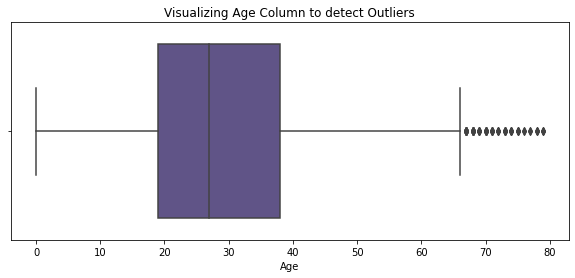

In [15]:
plt.figure(figsize=(10,4))
ax = sns.boxplot(num_data['Age'],color=my_colors[4])
ax.set_title('Visualizing Age Column to detect Outliers')
plt.show()

As we see that Our Hypothesis is right because Age Column does not have any outliers.

#### Checking RoomService Column

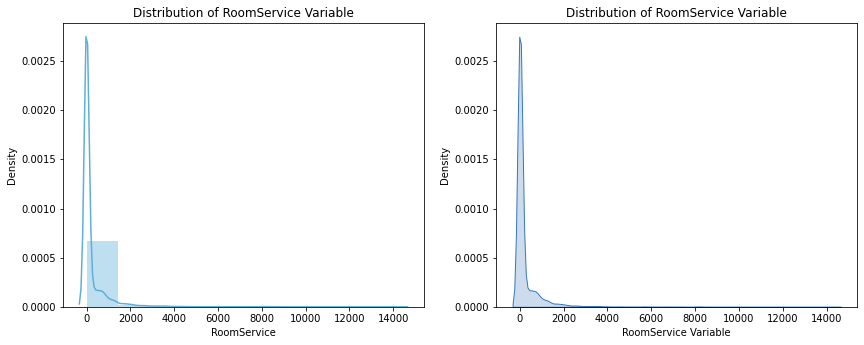

In [16]:
plt.figure(figsize=(22,24))
temp = num_data['RoomService']
x = pd.Series(temp,name='RoomService Variable')
plt.subplot(4,3,1)
ax = sns.distplot(temp,bins=10,color=my_colors[0])
ax.set_title("Distribution of RoomService Variable")
plt.subplot(4,3,2)
ax = sns.kdeplot(x,shade=True,color=my_colors[2])
ax.set_title('Distribution of RoomService Variable')
plt.show()

#### Interpretation
* We see that RoomService column is Not normalized and it is positively skewed.
* we can say that it have Outliers.
* To Confirm Our Hypothesis that RoomService Column have outliers, we Use Boxplot to Confirm it

**Detect Outliers in** RoomService Column **with boxplot**

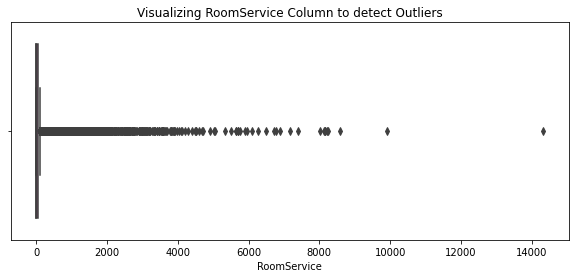

In [17]:
plt.figure(figsize=(10,4))
ax = sns.boxplot(num_data['RoomService'],color=my_colors[5])
ax.set_title('Visualizing RoomService Column to detect Outliers')
plt.show()

As our Hypothesis is right, RoomService Feature have Outliers. we will remove it in future after looking at other columns first.

#### Checking FoodCourt Column 

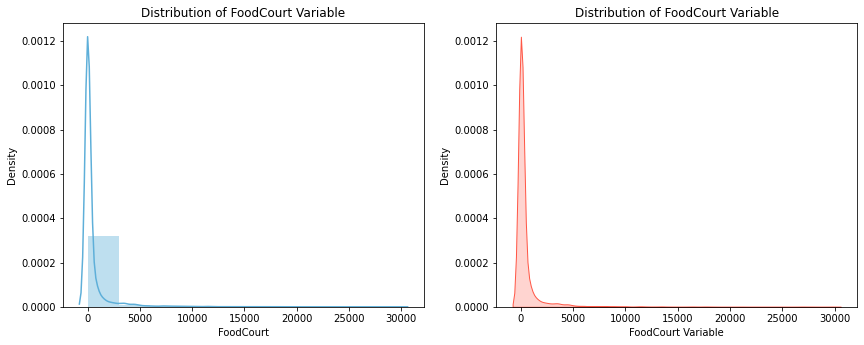

In [18]:
plt.figure(figsize=(22,24))
temp = num_data['FoodCourt']
x = pd.Series(temp,name='FoodCourt Variable')
plt.subplot(4,3,1)
ax = sns.distplot(temp,bins=10,color=my_colors[0])
ax.set_title("Distribution of FoodCourt Variable")
plt.subplot(4,3,2)
ax = sns.kdeplot(x,shade=True,color=my_colors[9])
ax.set_title('Distribution of FoodCourt Variable')
plt.show()

#### Interpretation
* We see that FoodCourt column is Not normalized and it is positively skewed.
* we can say that it have Outliers.
* To Confirm Our Hypothesis that FoodCourt Column have outliers, we Use Boxplot to Confirm it

**Detect Outliers in** FoodCourt Column **with boxplot**

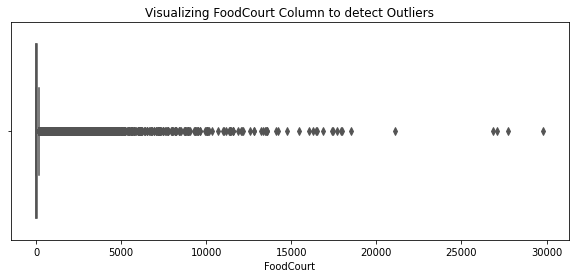

In [19]:
plt.figure(figsize=(10,4))
ax = sns.boxplot(num_data['FoodCourt'],color=my_colors[7])
ax.set_title('Visualizing FoodCourt Column to detect Outliers')
plt.show()

As our Hypothesis is right, FoodCourt Feature have Outliers.

#### Checking Spa Column


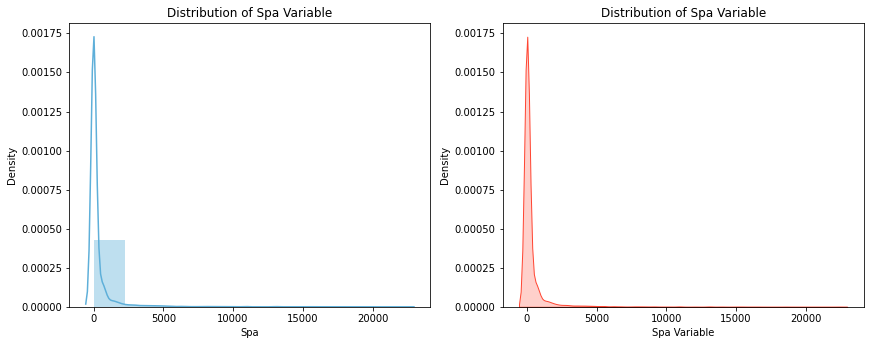

In [20]:
plt.figure(figsize=(22,24))
temp = num_data['Spa']
x = pd.Series(temp,name='Spa Variable')
plt.subplot(4,3,1)
ax = sns.distplot(temp,bins=10,color=my_colors[0])
ax.set_title("Distribution of Spa Variable")
plt.subplot(4,3,2)
ax = sns.kdeplot(x,shade=True,color=my_colors[8])
ax.set_title('Distribution of Spa Variable')
plt.show()

#### Interpretation
* We see that Spa column is Not normalized and it is positively skewed.
* we can say that it have Outliers.
* To Confirm Our Hypothesis that Spa Column have outliers, we Use Boxplot to Confirm it

**Detect Outliers in** Spa Column **with boxplot**

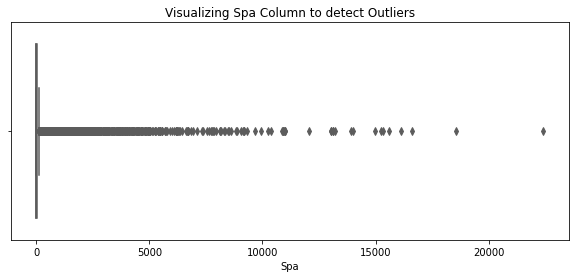

In [21]:
plt.figure(figsize=(10,4))
ax = sns.boxplot(num_data['Spa'],color=my_colors[8])
ax.set_title('Visualizing Spa Column to detect Outliers')
plt.show()

As our Hypothesis is right, Spa Feature have Outliers.

#### Checking ShoppingMall Column

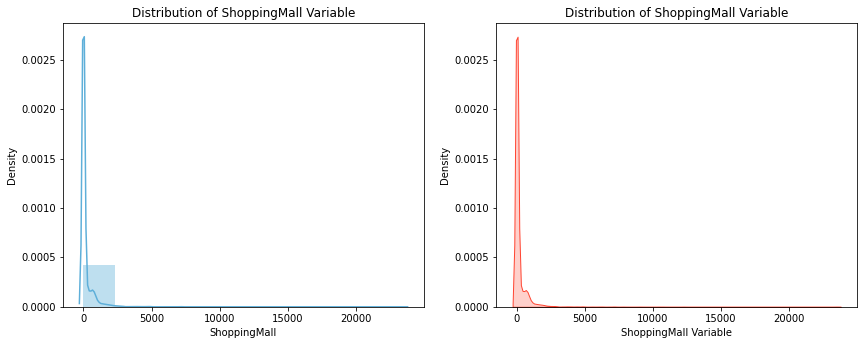

In [22]:
plt.figure(figsize=(22,24))
temp = num_data['ShoppingMall']
x = pd.Series(temp,name='ShoppingMall Variable')
plt.subplot(4,3,1)
ax = sns.distplot(temp,bins=10,color=my_colors[0])
ax.set_title("Distribution of ShoppingMall Variable")
plt.subplot(4,3,2)
ax = sns.kdeplot(x,shade=True,color=my_colors[8])
ax.set_title('Distribution of ShoppingMall Variable')
plt.show()

#### Interpretation
* We see that ShoppingMall column is Not normalized and it is positively skewed.
* we can say that it have Outliers.
* To Confirm Our Hypothesis that ShoppingMall Column have outliers, we Use Boxplot to Confirm it

**Detect Outliers in** ShoppingMall Column **with boxplot**

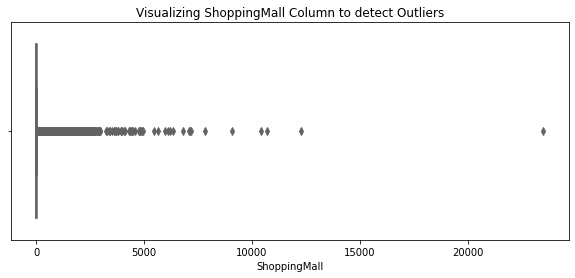

In [23]:
plt.figure(figsize=(10,4))
ax = sns.boxplot(num_data['ShoppingMall'],color=my_colors[9])
ax.set_title('Visualizing ShoppingMall Column to detect Outliers')
plt.show()

As our Hypothesis is right, ShoppingMall Feature have Outliers.

#### Checking VRDeck Column

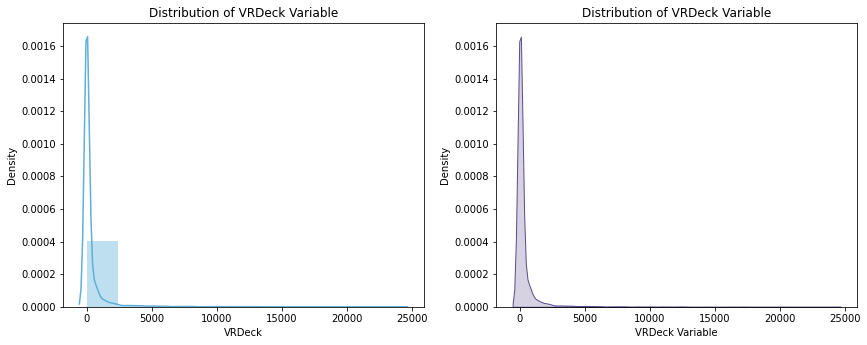

In [24]:
plt.figure(figsize=(22,24))
temp = num_data['VRDeck']
x = pd.Series(temp,name='VRDeck Variable')
plt.subplot(4,3,1)
ax = sns.distplot(temp,bins=10,color=my_colors[0])
ax.set_title("Distribution of VRDeck Variable")
plt.subplot(4,3,2)
ax = sns.kdeplot(x,shade=True,color=my_colors[4])
ax.set_title('Distribution of VRDeck Variable')
plt.show()

**Detect Outliers in** VRDeck Column **with boxplot**

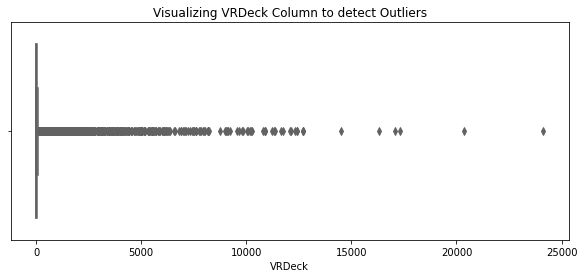

In [25]:
plt.figure(figsize=(10,4))
ax = sns.boxplot(num_data['VRDeck'],color=my_colors[9])
ax.set_title('Visualizing VRDeck Column to detect Outliers')
plt.show()

As our Hypothesis is right, VRDeck Feature have Outliers.

### Interpretation:

* Except Age column, Other are positively Skewed and they are not normalized. 
* RoomService, FoodCourt, ShoppingMall, VRDeck : These Columns have outliers as we detect it from boxplot 

## **Explore More** 👀

Text(40, 1700, 'Most of the People are from 18-30')

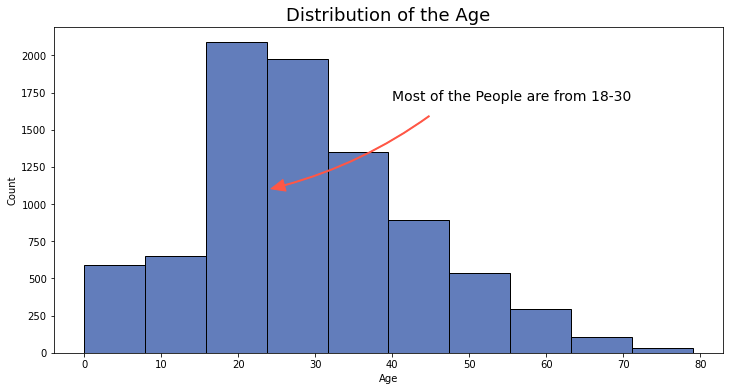

In [26]:
plt.figure(figsize=(12,6))
temp = num_data['Age']
x = pd.Series(temp,name='Age Variable')
ax = sns.histplot(temp,bins=10,color=my_colors[3])
ax.set_title('Distribution of the Age',fontsize=18)
style = "Simple, tail_width=1, head_width=12, head_length=14"
kw = dict(arrowstyle=style, color=my_colors[9])
arrow = patches.FancyArrowPatch((45, 1600), (24,1100),
                             connectionstyle="arc3,rad=-.10", **kw)
plt.gca().add_patch(arrow)

plt.text(x=40, y=1700, s=f"Most of the People are from 18-30", 
         color="black", size=14)

* As we clearly see that most of the people are from age 18-30.
* Now, we can find patterns from Column "Age", we can make it more useful by dividing to into standard age group.
* We divide the Age Column into four Groups => Children, Youth, Adult and Senior.

In [27]:
num_data['child'] = num_data['Age'].apply(lambda x: 1 if x>=1 and x<=14 else 0)
num_data['youth'] = num_data['Age'].apply(lambda x: 1 if x>=15 and x<=24 else 0)
num_data['adult'] = num_data['Age'].apply(lambda x: 1 if x>=25 and x<=64 else 0)
num_data['senior'] = num_data['Age'].apply(lambda x: 1 if x>=65 else 0)
num_data['Transported'] = num_data['Transported'].astype(int)

print(clr.S+" === Checking Age Group === "+clr.E,'\n')
print(f"There are : {sum(num_data['child'])} Childrens in Spaceship")
print(f"There are : {sum(num_data['youth'])} Youths in Spaceship")
print(f"There are : {sum(num_data['adult'])} Adult in Spaceship")
print(f"There are : {sum(num_data['senior'])} Senior in Spaceship\n\n")

 === Checking Age Group ===  

There are : 907 Childrens in Spaceship
There are : 2568 Youths in Spaceship
There are : 4754 Adult in Spaceship
There are : 107 Senior in Spaceship




#### Checking the Age Column More Deeply 

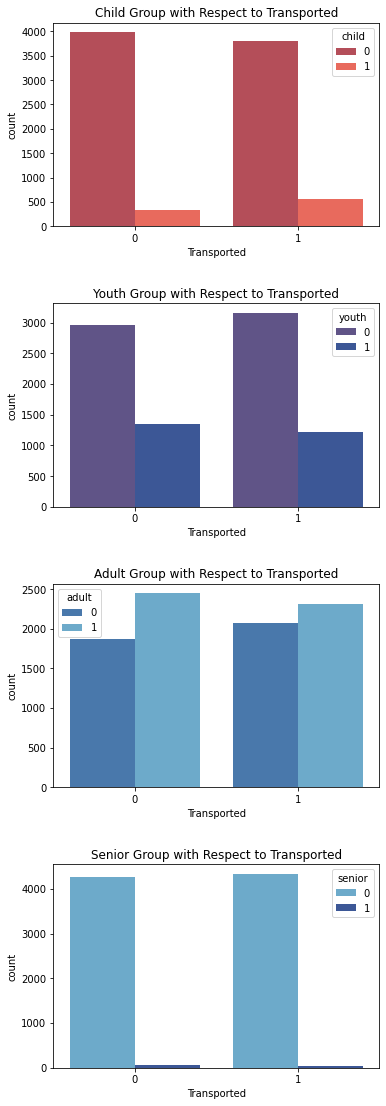

In [28]:
fig,ax = plt.subplots(4,1,figsize=(6,16))
sns.countplot(x='Transported',hue='child',data=num_data,ax=ax[0],palette=[my_colors[6],my_colors[9]])
ax[0].set_title('Child Group with Respect to Transported')
sns.countplot(x='Transported',hue='youth',data=num_data,ax=ax[1],palette=[my_colors[4],my_colors[3]])
ax[1].set_title('Youth Group with Respect to Transported')
sns.countplot(x='Transported',hue='adult',data=num_data,ax=ax[2],palette=[my_colors[2],my_colors[0]])
ax[2].set_title('Adult Group with Respect to Transported')
sns.countplot(x='Transported',hue='senior',data=num_data,ax=ax[3],palette=[my_colors[0],my_colors[3]])
ax[3].set_title('Senior Group with Respect to Transported')
plt.tight_layout(pad=3.0)
plt.show()

* Most of the People who Transported are youth and adult age group people.
* Basically, we find out that People who had more potential then others in terms of strength, they transported successfully.

#### Other Columns:

* we add up the remaining column because as we said previously that they can be count as the Expense of the Passengers into the Spaceship.
* Let's dive into these columns and find out insights from it ✌

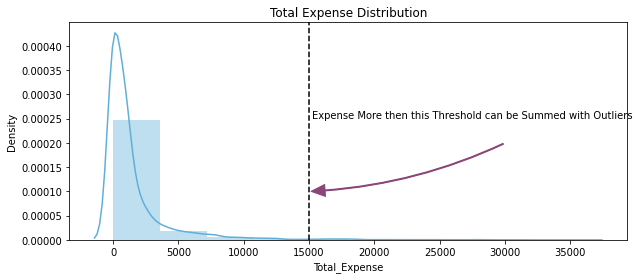

In [29]:
# We Summed up all the expense columns into one column and named it total expense.

num_data['Total_Expense'] = num_data['RoomService'] + num_data['Spa'] + num_data['ShoppingMall'] + num_data['VRDeck'] + num_data['FoodCourt']

# Now check the patterns behind it.

plt.figure(figsize=(10,4))
x=num_data['Total_Expense']
ax = sns.distplot(x,kde=True,bins=10,color=my_colors[0])
ax.set_title('Total Expense Distribution')
style = 'Simple, tail_width=1, head_width=12, head_length=14'
kw = dict(arrowstyle=style,color=my_colors[5])
arrow = patches.FancyArrowPatch((30000,0.00020),(15000,0.00010),connectionstyle='arc3,rad=-.10',**kw)
plt.gca().add_patch(arrow)
plt.text(x=15200, y=0.00025, s=f"Expense More then this Threshold can be Summed with Outliers", 
         color="black", size=10)
plt.axvline(x=15000,linestyle='--',color='black')
plt.show()

<div class="alert alert-info">  
<h3><strong>Now we Analyze Categorical Data</strong></h3>
</div>

In [30]:
cat_data = train_data.select_dtypes(exclude=['float']).copy() # Extracted the object type data
cat_data.head() # checking the data

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,False,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,False,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,True,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,False,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,False,Willy Santantines,True


### Summary of Categorical Columns:


* Numericals Columns : [PassengerId,HomePlanet,CryoSleep,Cabin,VIP,Name]

* All Columns are Categorical datatype, (Categorical means Object type).


#### Checking Nans in Categorical Columns

In [31]:
cat_data.isnull().sum()

PassengerId      0
HomePlanet     201
CryoSleep      217
Cabin          199
Destination    182
VIP            203
Name           200
Transported      0
dtype: int64

* Except PassengerId Column, we have Nan Columns
* Now we check Cardinality of Every Categorical Column, (Cardinality means => Frequency Distribution)



In [32]:
# Frequency Distribution of the categorical column

cat_data.nunique()

PassengerId    8693
HomePlanet        3
CryoSleep         2
Cabin          6560
Destination       3
VIP               2
Name           8473
Transported       2
dtype: int64

#### Interpretation



* There are Some Columns with High Frequency distribution and some are low.
* PassengerId, Name and Cabin Columns have High Frequency Distribution.
* HomePlanet, CryoSleep, Destination, VIP have low cardinality and low Frequency Distribution


# **Explore More** 👀

In [33]:
for col in cat_data.columns:
    print(cat_data[col].value_counts())

0001_01    1
6136_01    1
6141_01    1
6139_06    1
6139_05    1
          ..
3126_01    1
3124_03    1
3124_02    1
3124_01    1
9280_02    1
Name: PassengerId, Length: 8693, dtype: int64
Earth     4602
Europa    2131
Mars      1759
Name: HomePlanet, dtype: int64
False    5439
True     3037
Name: CryoSleep, dtype: int64
G/734/S     8
G/109/P     7
B/201/P     7
G/1368/P    7
G/981/S     7
           ..
G/556/P     1
E/231/S     1
G/545/S     1
G/543/S     1
F/947/P     1
Name: Cabin, Length: 6560, dtype: int64
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: Destination, dtype: int64
False    8291
True      199
Name: VIP, dtype: int64
Gollux Reedall        2
Elaney Webstephrey    2
Grake Porki           2
Sus Coolez            2
Apix Wala             2
                     ..
Jamela Griffy         1
Hardy Griffy          1
Salley Mckinn         1
Mall Frasp            1
Propsh Hontichre      1
Name: Name, Length: 8473, dtype: int64
True     4378
False    4315
Na

* As we see the data and can say that Name can not be useful for us because there is randomness in this column, so we can not find any patterns from it in this problem.

* ### Let's explore other columns individually

In [34]:
# Checking the Transported column

cat_data['Transported'].unique()

array([False,  True])

There are only two outputs => True if it is Transported or False if it is not Transported.

In [35]:
# Frequency distribution of True and False in Transported Column
print(clr.S+"Percentage of True and False" + clr.E)
print(round(cat_data['Transported'].value_counts()/len(cat_data['Transported']),3))

Percentage of True and False
True     0.504
False    0.496
Name: Transported, dtype: float64


### Visualize the Frequency distribution of Transported Column

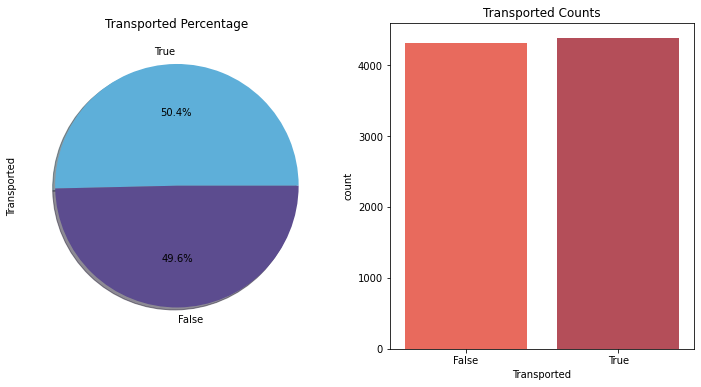

In [36]:
fig,ax = plt.subplots(1,2,figsize=(12,6))
ax[0] = cat_data['Transported'].value_counts().plot(kind='pie',
                                                    autopct='%.1f%%',
                                                    ax=ax[0],
                                                    colors=[my_colors[0],my_colors[4]],
                                                   shadow=True)
ax[0].set_title('Transported Percentage')

ax[1] = sns.countplot(x='Transported',data=cat_data,palette=[my_colors[9],my_colors[6]])
ax[1].set_title('Transported Counts')

plt.show()

* As we detect that the Transported Column is balanced

Now check **Homeplanet** Column with respect to Transported

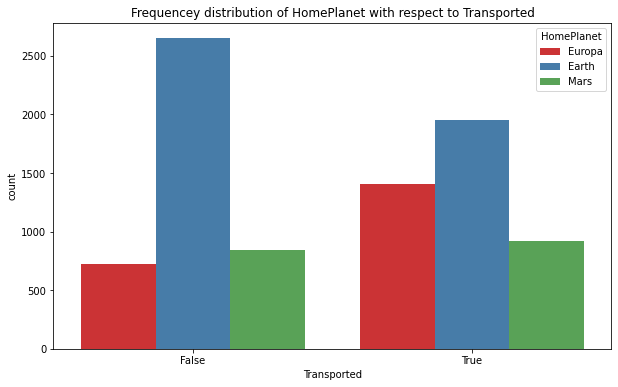

In [37]:
f , ax = plt.subplots(figsize=(10,6))
ax = sns.countplot(x='Transported',hue='HomePlanet',data=cat_data,palette='Set1')
ax.set_title('Frequencey distribution of HomePlanet with respect to Transported')
plt.show()

#### Interpretation


* Most of the Passenger in Spaceship belongs to Earth Homeplanet.
* Most of the Transported Passengers are from Homeplanet, then Europa and at last Mars.
* As we can conclude that, if a Passenger are from Earth Transported most. the reason behind it can be that People from Earth are the most nearest to the place to get Transported.


Now check **CryoSleep** Column with respect to Transported

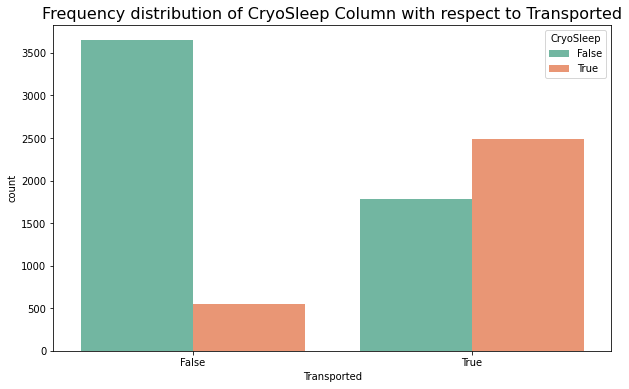

In [38]:
f,ax = plt.subplots(figsize=(10,6))
ax = sns.countplot(x='Transported',hue='CryoSleep',data=cat_data,palette = 'Set2')
ax.set_title('Frequency distribution of CryoSleep Column with respect to Transported',fontsize=16)
plt.show()

#### Interpretation


* This is an Important Column because it interprets that whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
* If a Person is in CryoSleep then, it get the most chances to be Transported.
* we concluded that people who were confined in their cabins are most likely to be Transported. the reason can be that they can be the Special People among Passengers and that's why most of the Passenger from CryoSleep Transported.


Now check **Destination** Column with respect to Transported

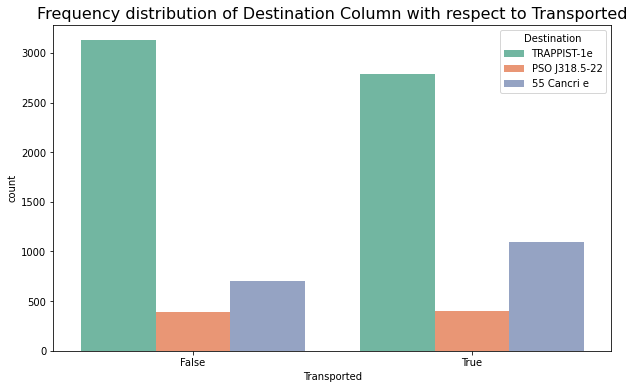

In [39]:
f,ax = plt.subplots(figsize=(10,6))
ax = sns.countplot(x='Transported',hue='Destination',data=cat_data,palette = 'Set2')
ax.set_title('Frequency distribution of Destination Column with respect to Transported',fontsize=16)
plt.show()

#### Interpretation


* TRAPPIST-1e is the Destination where most Passengers wants to debark there.
* as we conclude from the visualization that, most of the Passengers from TRAPPIST-1e Destination have Successfully Transported.
* There is a huge difference we see between TRAPPIST-1e Destination and Other two Destination. so, we can say that maybe the Spaceship were mostly nearer to the Destination "TRAPPIST-1e"


Now check **VIP** Column with respect to Transported

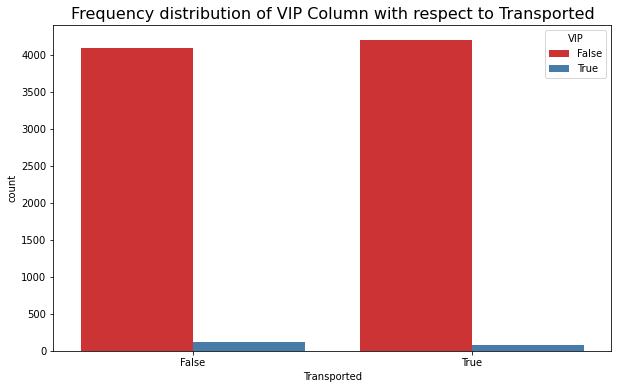

In [40]:
f,ax = plt.subplots(figsize=(10,6))
ax = sns.countplot(x='Transported',hue='VIP',data=cat_data,palette = 'Set1')
ax.set_title('Frequency distribution of VIP Column with respect to Transported',fontsize=16)
plt.show()

#### Interpretation


* As we clearly see that, Those Passengers who does not paid for VIP Services in their voyage, they likley to be Transported.
* The Reason can be that we have very low percentage of Passengers who does paid for VIP Services, that's why they have low Probability to be Transported instead of opposite Position Passengers.


**We Checked All Low Cardinality Categorical Columns (Features). Now we take a look into the High Cardinality Categorical Columns**

* Main Point: we will not Explore Name Column, as I defined on above cells.

### **Explore the Cabin Column**


* As I Read the Description of the Problem Statement and analyzes the column Cabin.
* I find out that Cabin Column can be broken into three more columns => Deck,Num,Side.
* These are the Columns which can be useful for Detecting wheather a Passenger can be Transported or not


In [41]:
cat_data['Cabin'] = cat_data['Cabin'].fillna(cat_data['Cabin'].mode()[0]) 

# Filling this because we have some Nans in Cabin
# we can not split it until we remove all the Nan from this column. so I filled it to Split this column into three new columns as I mentioned below

cat_data['Deck'] = cat_data['Cabin'].apply(lambda x: x.split('/')[0]) # Deck Column
cat_data['num'] = cat_data['Cabin'].apply(lambda x: x.split('/')[1])  # Num Column
cat_data['side'] = cat_data['Cabin'].apply(lambda x: x.split('/')[2]) # Side Column

print(cat_data['Deck'].value_counts())
print(cat_data['num'].value_counts())
print(cat_data['side'].value_counts())

F    2794
G    2758
E     876
B     779
C     747
D     478
A     256
T       5
Name: Deck, dtype: int64
734     208
82       28
86       22
19       22
56       21
       ... 
1644      1
1515      1
1639      1
1277      1
1894      1
Name: num, Length: 1817, dtype: int64
S    4487
P    4206
Name: side, dtype: int64


#### Interpretation


* we have Low Cardinality Columns are Deck and Side, but Num Column did not have low Cardinality.
* We First Explore the Deck and Side Column with respect to Transported.


Now check **Deck** Column with respect to Transported

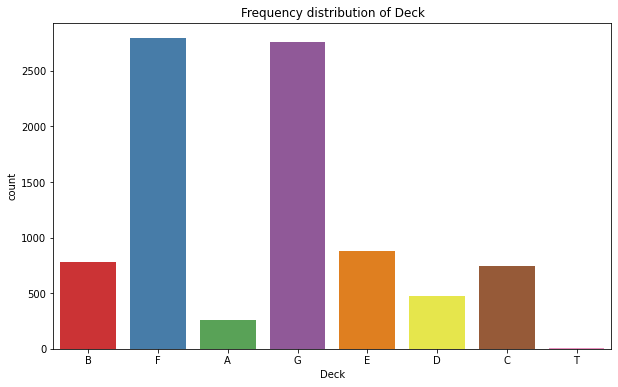

In [42]:
fig, ax = plt.subplots(figsize=(10,6))
ax = sns.countplot(x='Deck',data=cat_data,palette='Set1')
ax.set_title('Frequency distribution of Deck')
plt.show()

#### Interpretation

* As we see that Most Passengers are from Deck F and G.
* Deck T have the lowest Count of Passengers

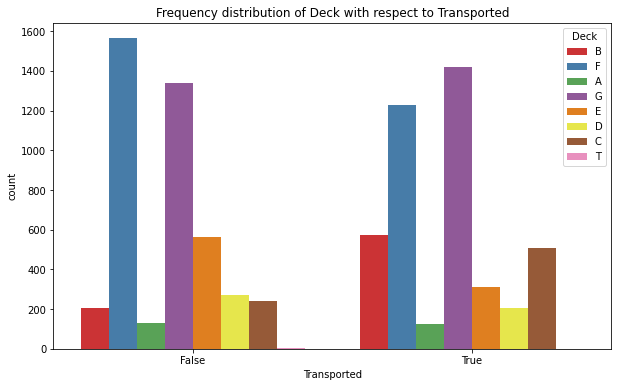

In [43]:
fig, ax = plt.subplots(figsize=(10,6))
ax = sns.countplot(x='Transported',hue='Deck',data=cat_data,palette='Set1')
ax.set_title('Frequency distribution of Deck with respect to Transported')
plt.show()

#### Interpretation


* As we concluded that Deck G have the Most Powerful or Impactful column on wheather a Passenger Transported or not.
* Deck F also have impact on Transported but as we see on above figure that Deck G have less frequency of Passengers then Deck F but it shows most Transported Deck.
* So, we can conclude that Deck G and Deck F Passengers are Most Likely to be Transported.
* Deck F and G can be the Position where Most of the Passengers belongs to Earth because Passengers from Earth Mostly had chances to be Transported.


### Let's explore the Column Deck with HomePlanet with respect to Transported.

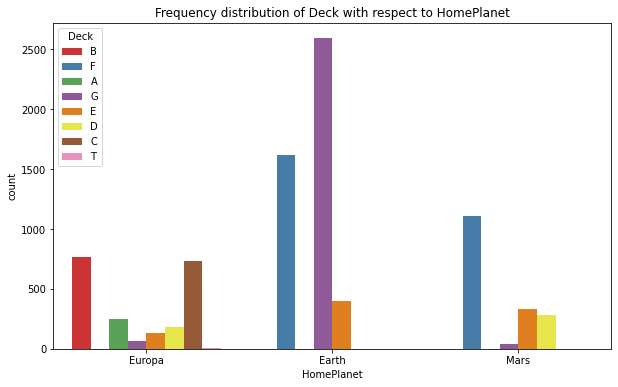

In [44]:
fig, ax = plt.subplots(figsize=(10,6))
ax = sns.countplot(x='HomePlanet',hue='Deck',data=cat_data,palette='Set1')
ax.set_title('Frequency distribution of Deck with respect to HomePlanet')
plt.show()

* As Our Hypothesis were Right: Most of the Passengers from HomePlanet Earth were belongs to the Deck G.
* Passengers from Earth HomePlanet + Deck G have the Highest Probability to be Transported.
* These features will help our Machine Learning Model to detect easily wheather a Passenger Transported or not.



Now check **side** Column with respect to Transported

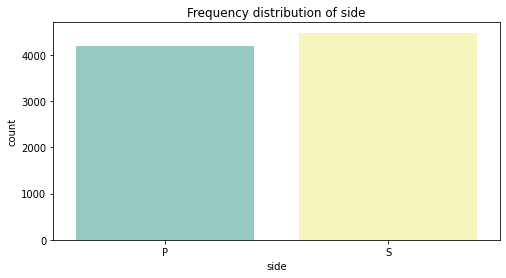

In [45]:
fig, ax = plt.subplots(figsize=(8,4))
ax = sns.countplot(x='side',data=cat_data,palette='Set3')
ax.set_title('Frequency distribution of side')
plt.show()

* This Column is Balanced and there is not any Big difference in frequency distribution of Data of Side Column.
* Side column have two values : S and P => S is Starboard and P is Port

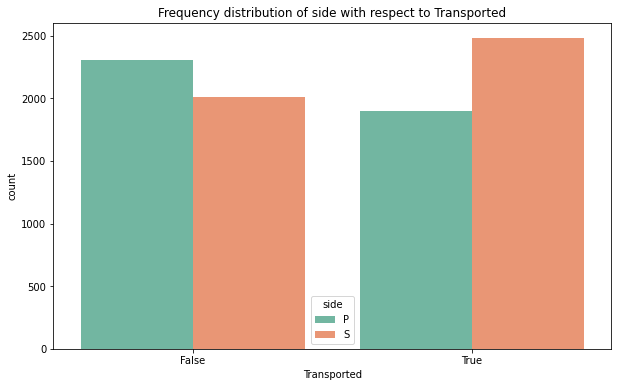

In [46]:
fig, ax = plt.subplots(figsize=(10,6))
ax = sns.countplot(x='Transported',hue='side',data=cat_data,palette='Set2')
ax.set_title('Frequency distribution of side with respect to Transported')
plt.show()

* Passengers from Starboard have much more Probability to be Transported.
* Now Our Hypothesis is : we can check that if Passengers are from Side S and Deck G are most likely to be Transported.

### Let's Explore Side Column with Deck Column to Find Pattern.

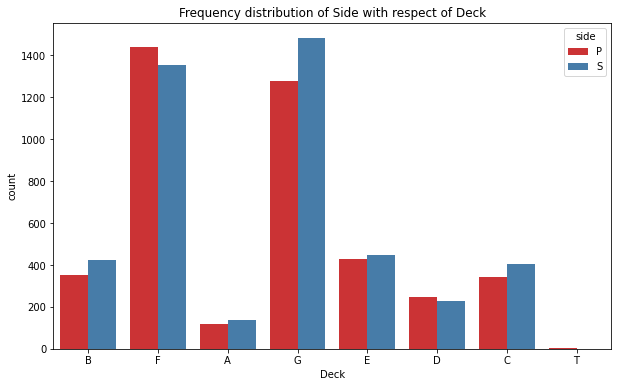

In [47]:
fig, ax = plt.subplots(figsize=(10,6))
ax = sns.countplot(x='Deck',hue='side',data=cat_data,palette='Set1')
ax.set_title('Frequency distribution of Side with respect of Deck')
plt.show()

* As our Hypothesis is Right: Most of the Passengers from Side S are from Deck G and Deck G Passengers are From HomePlanet Earth, which shows the highest probability to get Transported.

Now check **PassengerId** Column with respect to Transported

In [48]:
# PassengerId is the merge of two Data => group Id and the Passenger Id on that group.
# Passenger Id on different groups can be same.

cat_data['group_id'] = cat_data['PassengerId'].apply(lambda x: x.split('_')[0])
cat_data['No_of_family_members'] = cat_data['group_id'].map(cat_data['group_id'].value_counts())

print(cat_data['No_of_family_members'])

0       1
1       1
2       2
3       2
4       1
       ..
8688    1
8689    1
8690    1
8691    2
8692    2
Name: No_of_family_members, Length: 8693, dtype: int64


#### Interpretation

* No_of_Famliy_members is the New Column we Created it from PassengerId Column.
* We created this column by first understanding the Description of the Spaceship Titanic Problem.
* As the Problem Statement said that, Passengers belongs to some groups and often groups have Family Members most probably.
* So, we just calculated the group id from Passenger_Id for every Passenger and then just calculated the frequency of group id to count them up to Find No of Family Members for Every Passenger.


## More Exploration

# Encoding Categorical Data


* We can not load our Machine Learning Model with Categorical Data because ML Models can not understand String Data
* We must use technique to encode the Categorical Columns. there are many Techniques : LabelEncoding, One-hot-Encoding, TargetMeanEncoding and many more.
* We will Encode the Categorical Columns on the Basis of the Frequency distribution (Cardinality)
* We Use One-hot-Encoding for low Cardinality Columns and will use LabelEncoding for High Cardinality Columns.
* One-hot-Encoding: it is a type of encoding in which we create new columns with the values of that categorical column and assign 1 for yes and 0 for no. Like Column Side have two values S and P. it will create two columns S and P and then assign 1 and 0 in S and also Same for P.
* LabelEncoding: it is used when we have high cardinality column because if we have column which have 2000 different unique values in string, then we can not use one-hot-encoding beacause it will create 2000 columns which will be harder for us. so, we use LabelEncoding which encode on that column in which we are working on. it will assign numbers to every unique string in that particular column.


In [49]:
# we use one-hot-Encoding because we have low cardinality columns and high cardinality columns
# Like Name and PassengerId are dropped because Name Column is not Useful for us now and PassengerId is divided and we find 
# insightful column named No of family member.
# So, we Use One-Hot-Encoding by using pandas library. pd.get_dummies() => function used to create dummy columns which fullfill our plan


le = LabelEncoder()

print(pd.get_dummies(cat_data['Deck']))
print(le.fit_transform(cat_data['side']))
print(le.fit_transform(cat_data['HomePlanet']))
print(le.fit_transform(cat_data['Destination']))

      A  B  C  D  E  F  G  T
0     0  1  0  0  0  0  0  0
1     0  0  0  0  0  1  0  0
2     1  0  0  0  0  0  0  0
3     1  0  0  0  0  0  0  0
4     0  0  0  0  0  1  0  0
...  .. .. .. .. .. .. .. ..
8688  1  0  0  0  0  0  0  0
8689  0  0  0  0  0  0  1  0
8690  0  0  0  0  0  0  1  0
8691  0  0  0  0  1  0  0  0
8692  0  0  0  0  1  0  0  0

[8693 rows x 8 columns]
[0 1 1 ... 1 1 1]
[1 0 1 ... 0 1 1]
[2 2 2 ... 2 0 2]


<div class="alert alert-info">  
<h3><strong>Preprocessing</strong></h3>
</div>

* In Preprocessing, we fill the Nans and empty columns with some imputation techniques.
* To find any column containe Nan value, use Function .isnull().sum().
* Let's find out the Columns with Nan First.

In [50]:
train_data.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

#### Interpretation

* Columns with Nans: HomePlanet, CryoSleep, Cabin, Destination, Age, VIP, RoomService, FoodCourt, ShoppingMall, Spa, VRDeck, Name.
* numerical columns: Age,FoodCourt,ShoppingMall,Spa,VRDeck
* categorical columns: HomePlanet,CryoSleep,Destination,VIP,Name,Cabin
* we drop the Name Column because it will not help our model to detect wheather a Passenger is likely to be Transported or not.
* As we previously find out that numerical columns except Age have outliers. So, we can not impute or fill the Nans with mean because outliers have huge values or maybe some irrelevent values which will give us wrong mean. So, we fill the Nans with median it will be save for us.
* we fill the Categorical Columns with Simple Imputation technique => we fill the Nan with mode of that column. it will fill the Column with Most occurring value in that Particular column.

# **Let's Impute** 📐

In [51]:
def preprocess(df,name):
    
    df.drop('Name',axis=1,inplace=True) # drop the Name Column because it is not useful.
    
    # Numerical Column Imputation: 
    df['Age'] = df['Age'].fillna(df['Age'].mean()) # Age column does not have outliers so impute it with mean
    df['RoomService'] = df['RoomService'].fillna(df['RoomService'].median())
    df['Spa'] = df['Spa'].fillna(df['Spa'].median())
    df['FoodCourt'] = df['FoodCourt'].fillna(df['FoodCourt'].median())
    df['ShoppingMall'] = df['ShoppingMall'].fillna(df['ShoppingMall'].median())
    df['VRDeck'] = df['VRDeck'].fillna(df['VRDeck'].median())
    
    
    # Categorical Column Imputation:
    
    df['Cabin'] = df['Cabin'].fillna(df['Cabin'].mode()[0]) 
    df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode()[0])
    df['CryoSleep'] = df['CryoSleep'].fillna(df['CryoSleep'].mode()[0])
    df['VIP'] = df['VIP'].fillna(df['VIP'].mode()[0])
    df['Destination'] = df['Destination'].fillna(df['Destination'].mode()[0])
    
    # Removing Outliers:
    if name == 'Train':
        
        df.drop(df[df['RoomService'] > 10000].index,axis=0,inplace=True)
        df.drop(df[df['VRDeck'] > 20000].index,axis=0,inplace=True)
        df.drop(df[df['Spa'] > 20000].index,axis=0,inplace=True)
        df.drop(df[df['FoodCourt'] > 20000].index,axis=0,inplace=True)
        df.drop(df[df['ShoppingMall'] > 20000].index,axis=0,inplace=True)

    return df


train_data = preprocess(train_data,'Train') # calling the function to preprocess the Train data 
test_data = preprocess(test_data,'Test') # Same for Test data

#### Let's check the Nan.

In [52]:
print(clr.S+"Missing Train Data "+clr.E,train_data.isnull().sum().sum())
print(clr.S+"Missing Test Data "+clr.E,test_data.isnull().sum().sum())

Missing Train Data  0
Missing Test Data  0


<div class="alert alert-info">  
<h3><strong>Feature Engineering</strong></h3>
</div>

#### Interpretation

* we create new features from existing features in feature engineering.
* Some Columns Like: PassengerId, Cabin and Age, we can create new features from these mentioned columns.
* I explained new feature creation from these above mentioned featuress on above Cells.

### Now Let's dirty our hand and do Some Feature Engineering


In [53]:
def feature_engineering(df):
    
    df['Deck'] = df['Cabin'].apply(lambda x: x.split('/')[0]) # Deck Column
    df['num'] = df['Cabin'].apply(lambda x: x.split('/')[1])  # Num Column
    df['side'] = df['Cabin'].apply(lambda x: x.split('/')[2]) # Side Column

    # Age column can be divided into four Age groups.
    
    df['child'] = df['Age'].apply(lambda x: 1 if x>=1 and x<=14 else 0)
    df['youth'] = df['Age'].apply(lambda x: 1 if x>=15 and x<=24 else 0)
    df['adult'] = df['Age'].apply(lambda x: 1 if x>=25 and x<=64 else 0)
    df['senior'] = df['Age'].apply(lambda x: 1 if x>=65 else 0)
    
    # we calculated the Total Expense from column RoomService, Spa, ShoppingMall, VRDeck and FoodCourt
    df['Total_Expense'] = df['RoomService'] + df['Spa'] + df['ShoppingMall'] + df['VRDeck'] + df['FoodCourt']
    
    # we excluded the group_id column from PassengerId and calculated the no of family members from group_id
    
    df['group_id'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
    df['No_of_family_members'] = df['group_id'].map(df['group_id'].value_counts())
    
    # Label Encoding:
    
    le = LabelEncoder()
    df['CryoSleep'] = le.fit_transform(df['CryoSleep'])
    df['VIP'] = le.fit_transform(df['VIP'])
    df['HomePlanet'] = le.fit_transform(df['HomePlanet'])
    df['Destination'] = le.fit_transform(df['Destination'])
    df['side'] = le.fit_transform(df['side'])
    df['num'] = le.fit_transform(df['num'])
    
    # One-Hot-Encoding:
    
    dff = pd.get_dummies(df['Deck'])
    dff['PassengerId'] = df['PassengerId']
    df = pd.merge(df,dff,on='PassengerId')
    
    #df['Deck'] = le.fit_transform(df['Deck'])
    
    
    
    return df
    
train_data = feature_engineering(train_data)
test_data = feature_engineering(test_data)

<div class="alert alert-info">  
<h3><strong>Feature Selection</strong></h3>
</div>

* In Feature Selection, we select important features between these all features of table.
* A great Notebook is based on feature selection
[Comprehensive Guide on Feature Selection](https://www.kaggle.com/code/prashant111/comprehensive-guide-on-feature-selection)

#### Correlation Technique:


* First we remove those features which have correlation of 0.8 or greater than 0.8. 0.8 is the threshold or we can say that limit. you can set this on the basis of your data and problem

In [54]:
def remove_feature(df,thresh):
    corr_col = set()
    correlation = df.corr()
    for i in range(len(correlation.columns)):
        for j in range(i):
            if abs(correlation.iloc[i,j]) > thresh:
                column = correlation.columns[i]
                corr_col.add(column)
    return corr_col

correlated_features = remove_feature(train_data,0.8)
print(f'Highly correlated Features : {correlated_features}')

Highly correlated Features : set()


* As we find out that side_S Feature have correlation greater than 0.8 which can reduce the accuracy of our Model.
* we will check our Model by dropping this Column.

* We now drop columns like PassengerId, Cabin, HomePlanet, Destination, group_id, Deck, side because we created New features from these feature.

In [55]:

train_data.drop(['PassengerId','Cabin','group_id','Deck','Age'],axis=1,inplace=True)
test_data.drop(['PassengerId','Cabin','group_id','Deck','Age'],axis=1,inplace=True)

In [56]:
# Checking the data after some updation.


train_data.head()

,HomePlanet,CryoSleep,Destination,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,...,Total_Expense,No_of_family_members,A,B,C,D,E,F,G,T
0,1,0,2,0,0.0,0.0,0.0,0.0,0.0,False,...,0.0,1,0,1,0,0,0,0,0,0
1,0,0,2,0,109.0,9.0,25.0,549.0,44.0,True,...,736.0,1,0,0,0,0,0,1,0,0
2,1,0,2,1,43.0,3576.0,0.0,6715.0,49.0,False,...,10383.0,2,1,0,0,0,0,0,0,0
3,1,0,2,0,0.0,1283.0,371.0,3329.0,193.0,False,...,5176.0,2,1,0,0,0,0,0,0,0
4,0,0,2,0,303.0,70.0,151.0,565.0,2.0,True,...,1091.0,1,0,0,0,0,0,1,0,0


<div class="alert alert-info">  
<h3><strong>Scaling</strong></h3>
</div>

#### Interpretation

* we have different columns with different variance. Some columns have high variance and some of them have low variance.
* So there is a technique of scaling the columns(features), it standardize the columns and variance will be same for all columns. why we are doing this because if we have high variance then our ML Model have the chance to get over fitted. 
* Overfitting means that our ML Model shows good accuracy on Train data and show very low accuracy on Test data.
* So, we scale it using sklearn.preprocessing function name: StandardScaler. 

In [57]:
def Scaling(df,name):
    
    if name == 'train':
        t_data = df.copy().drop('Transported',axis=1)
        ss = StandardScaler()
        ss.fit(t_data)
        dff = pd.DataFrame(ss.transform(t_data),index=t_data.index,columns=t_data.columns)
        dff['Transported'] = df['Transported']
    
    else:
        ss = StandardScaler()
        ss.fit(df)
        dff = pd.DataFrame(ss.transform(df),index=df.index,columns=df.columns)
        
    return dff

train = Scaling(train_data,'train')
test = Scaling(test_data,'test')

In [58]:
y = train['Transported']
train.drop('Transported',axis=1,inplace=True)

Here we see that the Variance of all columns are Same Now.

<div class="alert alert-info">  
<h3><strong>Modeling</strong></h3>
</div>

#### Interpretation

* our data is ready to fit on the Machine Learning Model.
* First, we need to split the data into train and validate. we split the Training data into 70-30%. 70% of the data used for training and 30% for validation.
* we try to Use Different ML Models to check the accuracy score. so, we will further use cross_validation technique if we get less accuracy on our models.

#### **Splitting of Data**

In [59]:
# split the data into 70-30 portion.

x_train,x_test,y_train,y_test = train_test_split(train,y,test_size=0.3)


In [60]:
print(clr.S+"Training Size = "+clr.E, len(x_train))
print(clr.S+"Validation Size = "+clr.E, len(x_test))

Training Size =  6078
Validation Size =  2605


#### **Fitting the Model**

In [61]:
model = RandomForestClassifier(n_estimators=500,max_depth=7)
model.fit(x_train,y_train)

RandomForestClassifier(max_depth=7, n_estimators=500)

#### **Validation**

In [62]:
model.score(x_test,y_test)

0.800383877159309

#### Checking Overfitting

In [63]:
print(model.score(x_train,y_train))
print(model.score(x_test,y_test))

0.8200065811122079
0.800383877159309


* As we see that the difference between train data and validation data accuracy is very low and their accuracy are similar. 
* Our Model is not overfitted.

### **Confusion Matrix For this Model**

* This will show that how many prediction is right and how much is not.

<AxesSubplot:title={'center':'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

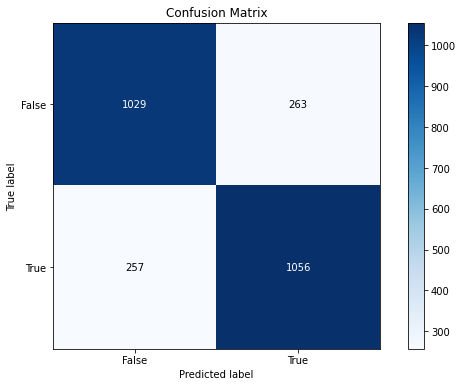

In [64]:
y_pred = model.predict(x_test)



skplt.metrics.plot_confusion_matrix(
    y_test, 
    y_pred,
    figsize=(10,6))

### **You can Improve the Score using different kind of Models and HyperParameter tuning.**

#### **I Hope this Notebook Helps you a Lot. Comment your feedback :)**
#### **Happy Ending** ✌